Задание 2:

По каждому из классов (business, entertainment, politics, sport, tech) вам необходимо взять каждый класс и смоделировать распределение топиков (тем) по каждому из классов и построить визуализации. Необходимо объяснить о чем больше всего говорится в каждом из классов, то есть сделать на основании вашей работы анализ по каждому из классов. Используем любой подход, который вам известен для задачи Topic Modelling. 

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator
import warnings
warnings.filterwarnings("ignore")

In [2]:
DATA_DIR = "./data/bbc/"

class BbcDataset:
    def __init__(self, data_dir=DATA_DIR):
        self.data_dir = data_dir
        self.documents = [
            os.path.join(path, name)
            for path, _, files in os.walk(self.data_dir)
            for name in files
        ]
        self.dataframe = self.get_pandas_alike_dataset()

    def get_dataset(self):
        """Загружает все документы и их категории"""
        data = []
        for file in self.documents:
            label = os.path.basename(os.path.dirname(file))
            try:
                with open(file, "r", encoding="utf-8") as f:
                    content = f.read().strip()
                data.append((content, label))
            except Exception as e:
                print(f"Ошибка чтения файла {file}: {e}")
        return data

    def get_pandas_alike_dataset(self):
        """Возвращает DataFrame с текстами и метками"""
        data = self.get_dataset()
        return pd.DataFrame(data, columns=["text", "label"])

In [3]:
bbc_dataset = BbcDataset()
df = bbc_dataset.get_pandas_alike_dataset()

# избавимся от дупликатов новостей
df = df.drop_duplicates(subset=['text'])

In [4]:
# переиспользуем препаратор для очистки текста из решения задания 1
from nltk.tokenize import RegexpTokenizer
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
import spacy

# загружаем spaCy
nlp = spacy.load("en_core_web_sm")

# дополнительные стоп-слова 
additional_stop_words = {
    'say', 'go', 'get', 'would', 'make', 'could', 'can', 'may', 
    'take', 'come', 'give', 'look', 'find', 'use', 'tell', 'ask', 
    'work', 'seem', 'feel', 'try', 'leave', 'call', 'good', 'well', 
    'think', 'also', 'even', 'know', 'want', 'year', 'time', 'new'
}

class TextPreparator(BaseEstimator):
    def __init__(self):
        # настраиваем токенизатор на латинские буквы и цифры
        # токенизатор проигнорирует \n, \r, \t, пунктуацию и лишние пробелы
        tokenizer = RegexpTokenizer(r'[a-z0-9]+')
        # приводим к нижнему регистру, избавляемся от дефисов (нормализируем) и токенизируем
        tokenize_func = lambda text: [
            word for word in tokenizer.tokenize(text.lower().replace('-', ''))
        ]
        
        # проводим лемматизацию 
        lemmatize_func = lambda tokens: [t.lemma_ for t in nlp(" ".join(tokens))] if tokens else []
        
        # проводим очистку от стоп-слов 
        stop_words = set(stopwords.words('english')).union(additional_stop_words)
        stop_words_filter_func = lambda tokens: [
            word for word in tokens if word not in stop_words
        ]

        # векторизуем для NumPy массива
        self.v_tokenize = np.vectorize(tokenize_func, otypes=[object])
        self.v_lemmatize = np.vectorize(lemmatize_func, otypes=[object])
        self.v_remove_stop_words = np.vectorize(stop_words_filter_func, otypes=[object])

    def fit(self, X, y):
        self.is_fitted_ = True
        return self

    def transform(self, X):
        # шаг 1: нормализация, токенизация и фильтрация по стоп-словам
        tokens_result = self.v_tokenize(X)

        # шаг 2: лемматизация
        lemmatized_result = self.v_lemmatize(tokens_result)

        # шаг 3: удаление стоп-слов
        final_result = self.v_remove_stop_words(lemmatized_result)
        
        return final_result

In [5]:
from sklearn.pipeline import Pipeline

preparator = Pipeline([
    ("preparator", TextPreparator())
])
# fit не проводит никакого обучения
preparator.fit(df.text, df.label)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preparator', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False


In [6]:
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np

def visualize_class_topics(df, spec_stop_words, no_above=0.8):    
    tokens_list = preparator.transform(df) 
    
    # уберем токены, состоящие только из цифр или из одного символа, и специализированные стоп-слова
    tokens_list = np.array([
        [token for token in tokens 
         if not (isinstance(token, str) and token.isdigit() or len(token) <= 1) and token not in spec_stop_words] 
        for tokens in tokens_list
    ], dtype=object)

    # представление данных в Gensim словарем и корпусом
    # сформируем словарь и корпус векторного представления
    dictionary = Dictionary(tokens_list)
    dictionary.filter_extremes(
        no_below=10,      # убрать слова, которые встерчаются меньше чем в 10 документах
        no_above=no_above,    # убрать слова, которые встречаются более чем в no_above*100 % документов 
        keep_n=10000    # оставить топ самых частых
    )
    corpus = [dictionary.doc2bow(tokens) for tokens in tokens_list]

    # рассмотрим латентное размещение Дирихле
    lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=3, 
                   alpha='auto', eta='auto', iterations = 50, passes = 10,
                   random_state=42)

    # визуализируем в виде облаков токенов
    plot_token_clouds(lda, num_topics_to_show = 3, words_per_topic = 10)
    # визуализируем в виде горизонтальных Bar Charts
    plot_top_words(lda, n_topics=3, n_words=10)
    # визуализируем расстояния между темами
    mdiff, annotation = lda.diff(lda, distance='jaccard', num_words=10)
    plot_difference(mdiff, title="Отличие тем LDA [по jaccard дистанции]")

In [7]:
# визуализация в виде облаков токенов
def plot_token_clouds(lda_model, num_topics_to_show = 3, words_per_topic = 10):
    """Визуализирует облака топ-слов для первых n_topics тем."""
    
    # создаем сетку: 1 строка, n колонок
    fig, axes = plt.subplots(1, num_topics_to_show, figsize=(20, 10), sharex=True, sharey=True)
    
    for i, ax in enumerate(axes):
        # получаем топ-слова для текущей темы
        topic_words = dict(lda_model.show_topic(i, topn=words_per_topic))
        
        # генерируем облако
        cloud = WordCloud(background_color='white', width=400, height=400).generate_from_frequencies(topic_words)
        
        ax.imshow(cloud, interpolation='bilinear')
        ax.set_title(f'Тема №{i + 1}', fontsize=16)
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

In [8]:
# визуализация в виде горизонтальных Bar Charts
def plot_top_words(lda_model, n_topics=3, n_words=10):
    """Визуализирует топ-слова для первых n_topics тем."""
    
    # Создаем сетку графиков: 1 строка, n_topics колонок
    fig, axes = plt.subplots(1, n_topics, figsize=(20, 8), sharey=False)
    fig.subplots_adjust(top=0.9, bottom=0.1, hspace=0.3, wspace=0.4)

    for i in range(n_topics):
        # получаем данные темы: (слово, вероятность)
        topic_data = lda_model.show_topic(i, topn=n_words)
        words = [word for word, prob in topic_data]
        probs = [prob for word, prob in topic_data]
        
        ax = axes[i]
        # строим горизонтальный график
        y_pos = np.arange(len(words))
        ax.barh(y_pos, probs, align='center', color='skyblue')
        
        # настройка осей
        ax.set_yticks(y_pos)
        ax.set_yticklabels(words, fontsize=12)
        ax.invert_yaxis()  # Самое важное слово — сверху
        ax.set_title(f'Тема №{i + 1}', fontsize=14, fontweight='bold')
        ax.set_xlabel('Вероятность')

    plt.suptitle('Топ-слова по темам LDA', fontsize=18)
    plt.show()

In [9]:
import plotly.offline as py
import plotly.graph_objs as go
import plotly.io as pio

py.init_notebook_mode()

def plot_difference(mdiff, title=""):
    """Визуально определяет расстояния между темами LDA модели."""
    
    ticks = list(range(1, len(mdiff) + 1))
    
    fig = go.Figure(data=go.Heatmap(
        z=mdiff, x=ticks, y=ticks, 
        colorscale='RdBu',
        text=mdiff, texttemplate="%{text:.2f}"
    ))
    
    fig.update_layout(
        width=500, 
        height=500, 
        title=title, 
        xaxis=dict(title="Тема", dtick=1), 
        yaxis=dict(title="Тема", dtick=1)
    )
    fig.show(renderer="png")

## Проведем анализ классов по темам с помощью латентного размещения Дирихле [LDA], по распределению вероятностей по словам

## Рассмотрим тему 'sport'

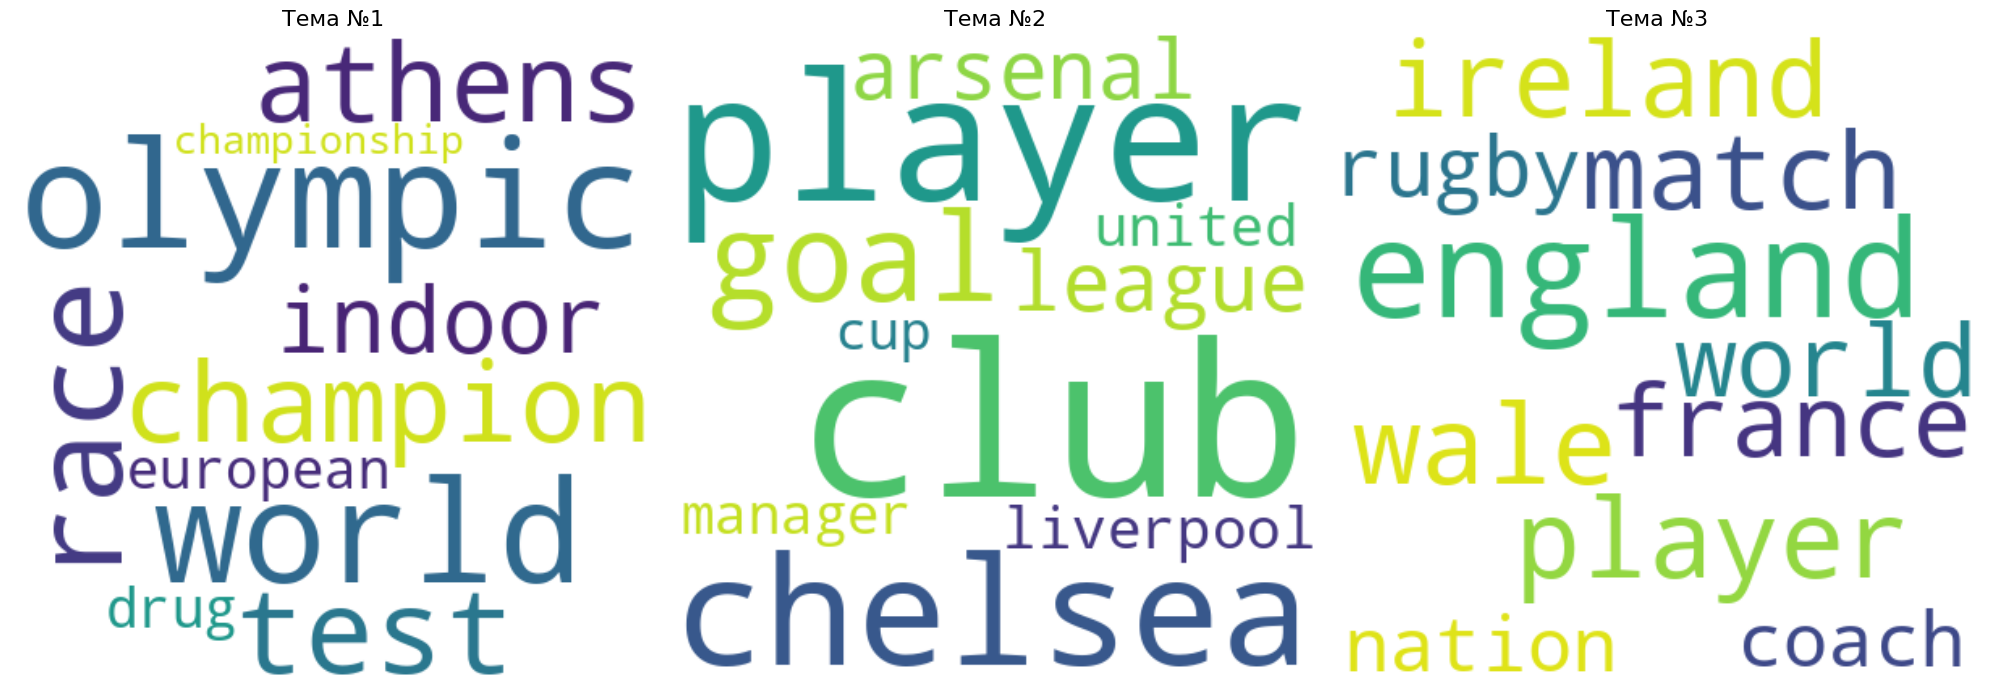

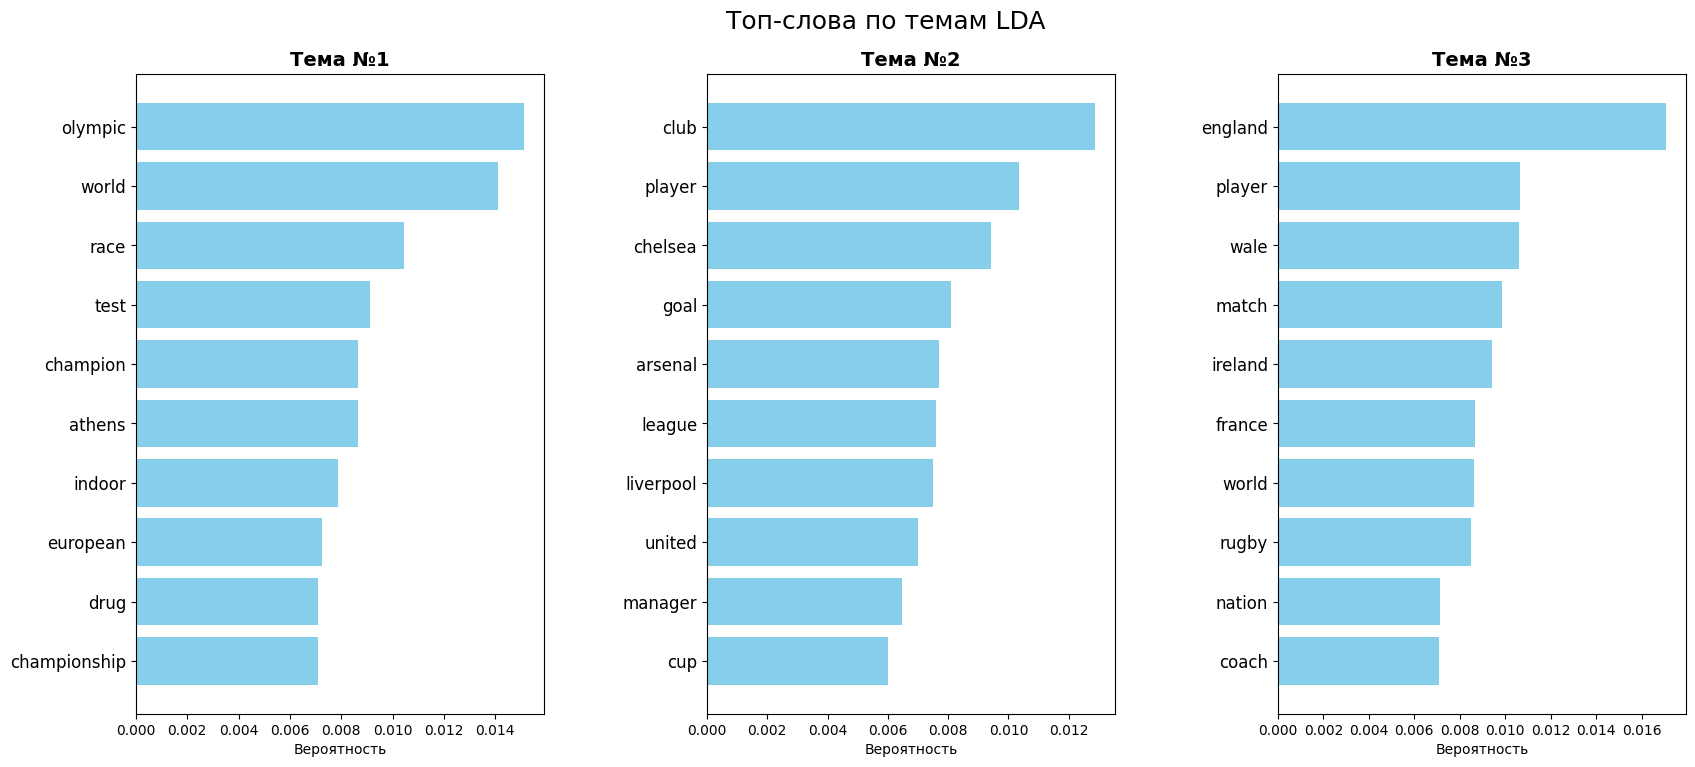

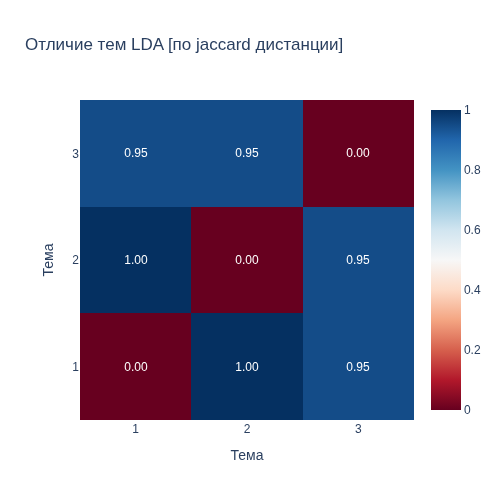

In [10]:
sport_df = df.text[df["label"] == 'sport']

# стоп-слова для sport
sport_stop_words = {
    'win', 'game', 'one', 'two', 'three', 'four', 'five', 'six',
    'set', 'like', 'sport', 'first', 'second', 'last', 'back', 'open', 'minute',
    'beat', 'run', 'side', 'add',
}
visualize_class_topics(sport_df, sport_stop_words, no_above=0.5)

По теме 'sport' подобраны три темы, сильно отличающиеся по jaccard дистанции.\
&emsp;&emsp; Первая тема - олимпийские игры (чемпионат мира) в закрытом помещении.\
&emsp;&emsp; Вторая тема - клубная игровая лига среди английских футбольных команд.\
&emsp;&emsp; Третья тема - матчи по регби (чемпионат мира?) между Англией, Ирландией, Францией.

## Рассмотрим тему 'business'

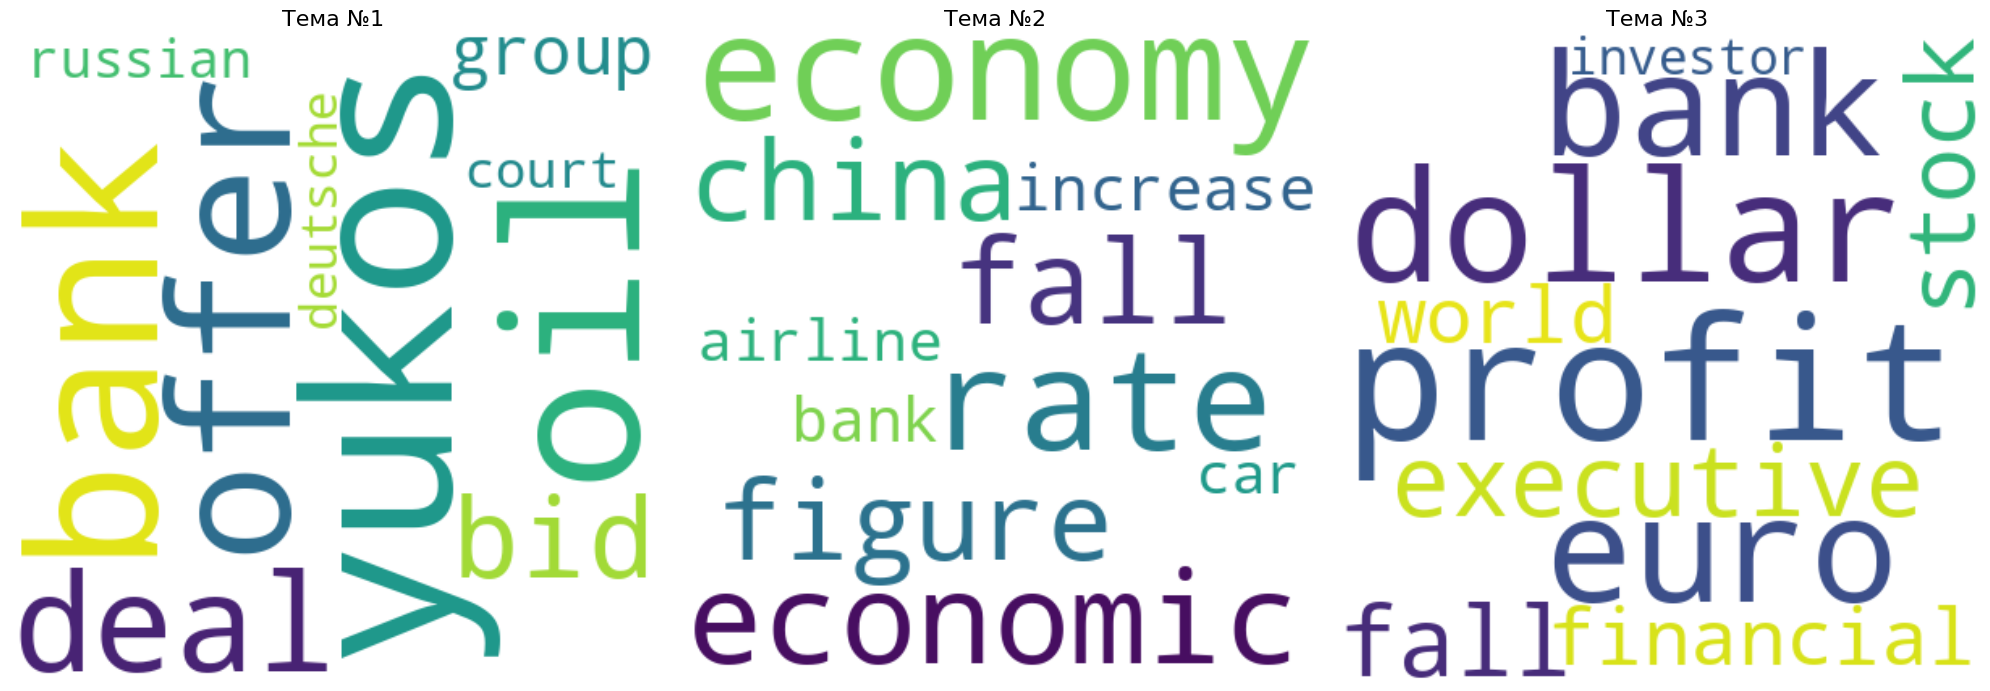

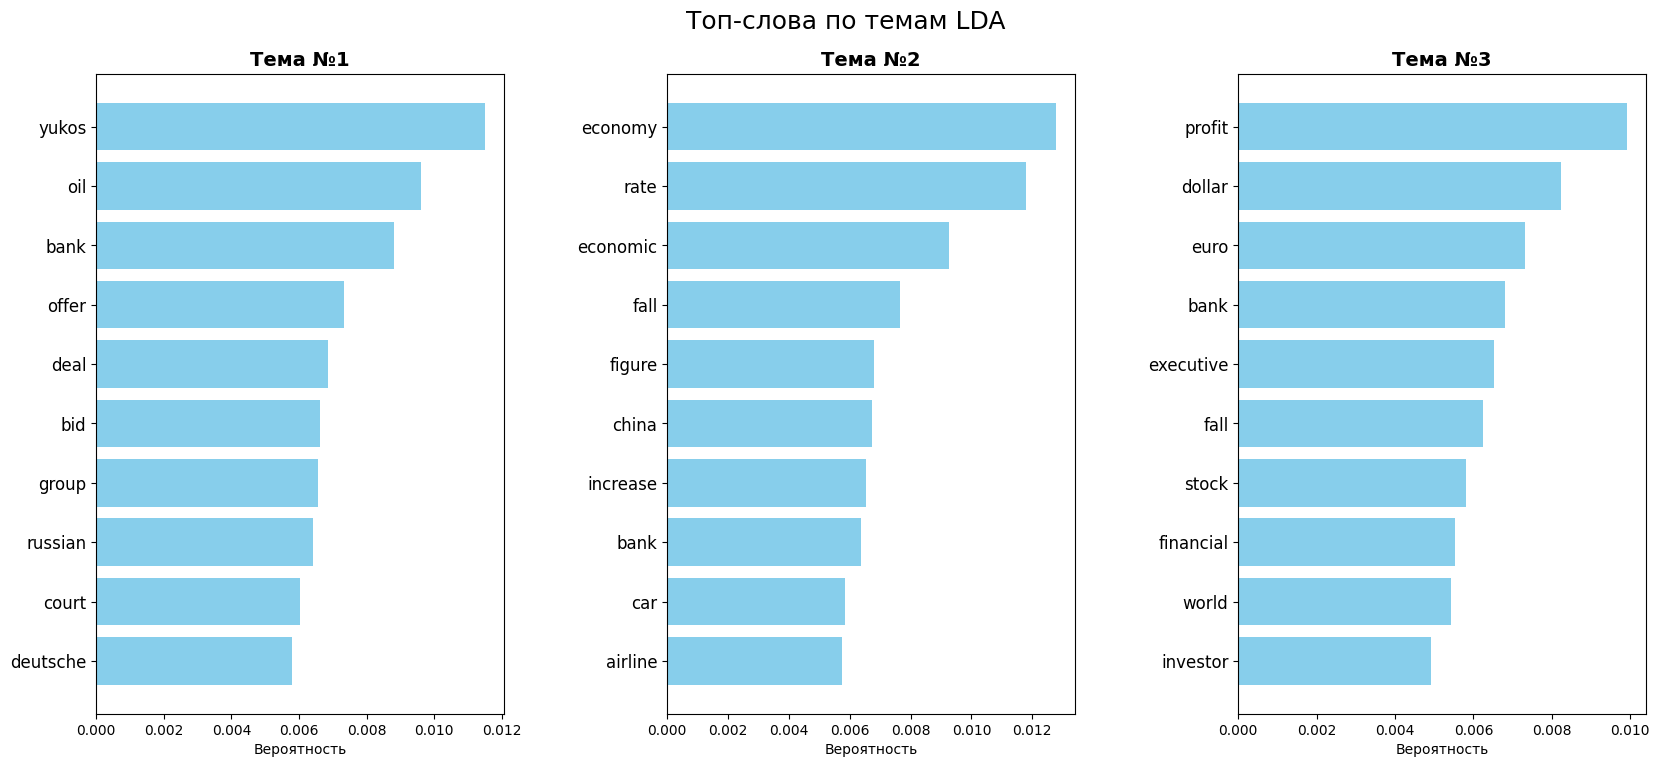

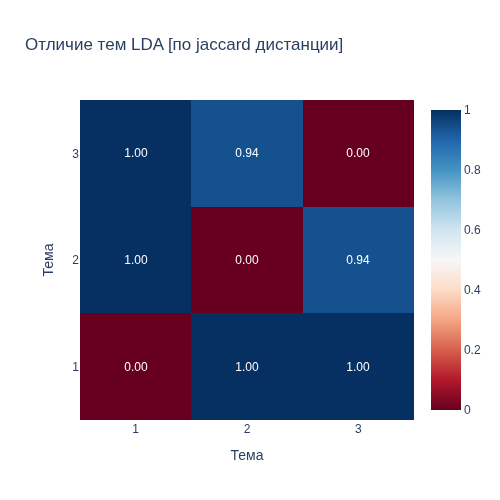

In [11]:
business_df = df.text[df["label"] == 'business']

# стоп-слова для business
business_stop_words = {
    "mr", "first", "last" 
}
visualize_class_topics(business_df, business_stop_words, no_above=0.3)

По теме 'business' подобраны три темы, сильно отличающиеся по jaccard дистанции.\
&emsp;&emsp; Первая тема - предложение/сделка по российской нефтяной компании.\
&emsp;&emsp; Вторая тема - увеличение/падение темпов экономического роста, связанные с Китаем, банками.\
&emsp;&emsp; Третья тема - финансовая прибыль (в долларах, евро) у банков, инвесторов, управляющих, от акций.

## Рассмотрим тему 'entertainment'

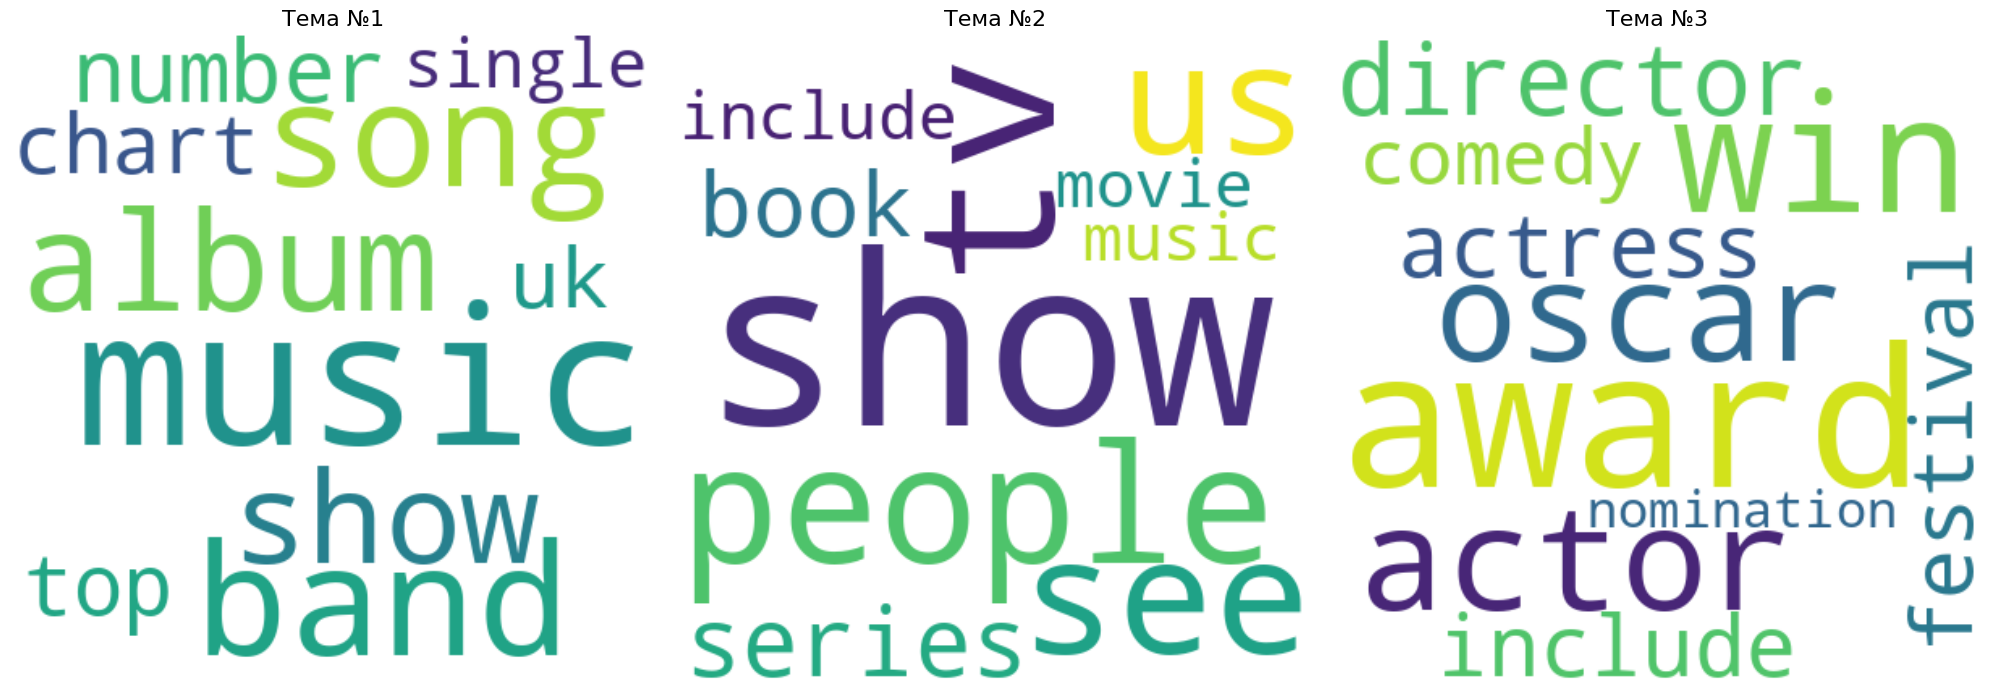

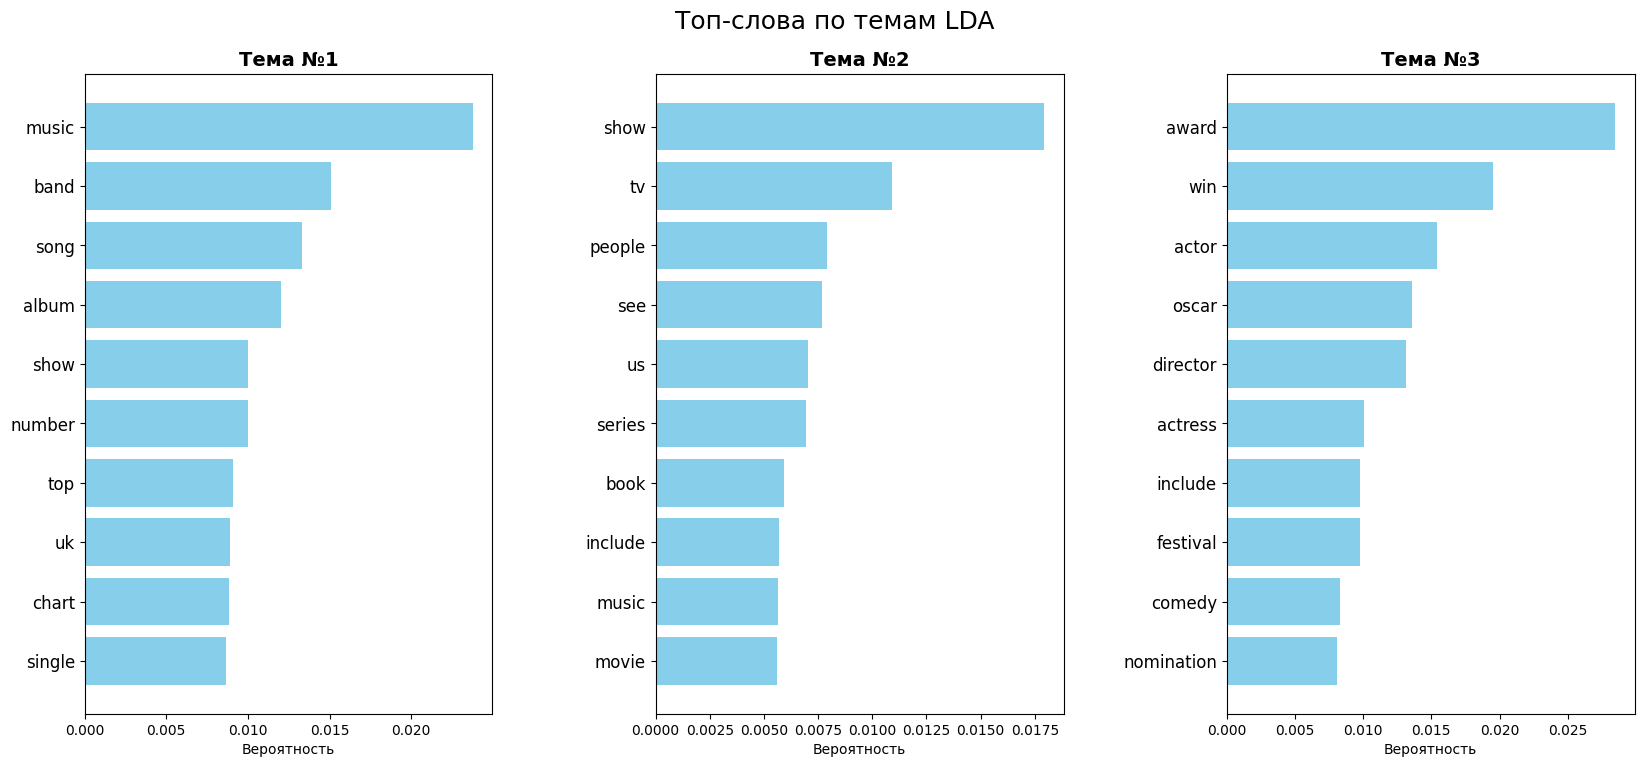

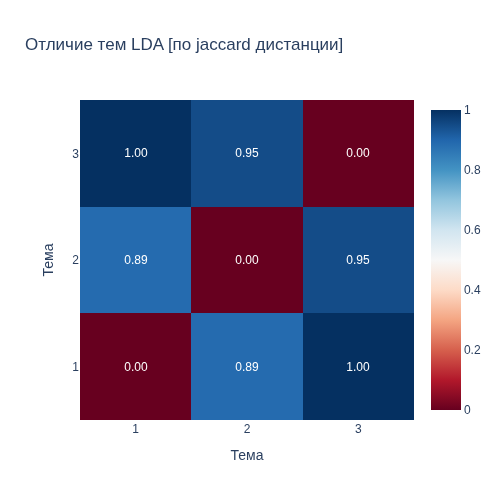

In [12]:
entertainment_df = df.text[df["label"] == 'entertainment']

# стоп-слова для entertainment
entertainment_stop_words = {
    'one', 'two', 'three', 'four', 'five', 'six',
    'first', 'second', 'last', "mr"
}
visualize_class_topics(entertainment_df, entertainment_stop_words, no_above=0.5)

По теме 'entertainment' подобраны три темы, сильно отличающиеся по jaccard дистанции.\
&emsp;&emsp; Первая тема - британский топ-чарт музыкальных групп/альбомов.\
&emsp;&emsp; Вторая тема - серия (американских?) телевизионных шоу о книгах, музыке, фильмах.\
&emsp;&emsp; Третья тема - премия Оскар победителям среди актеров, режиссеров.

## Рассмотрим тему 'politics'

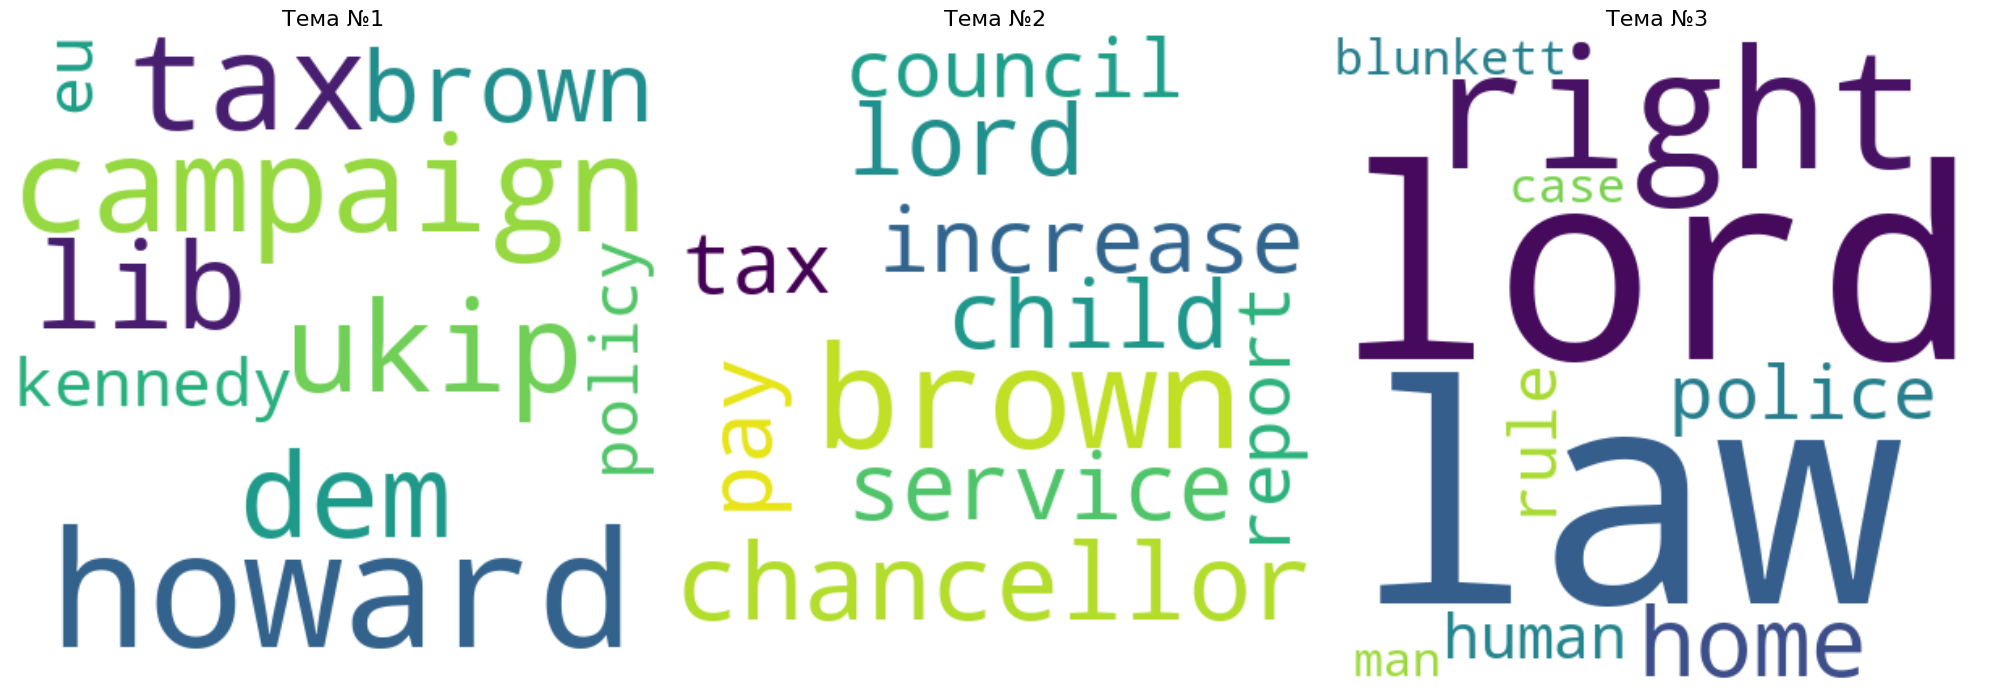

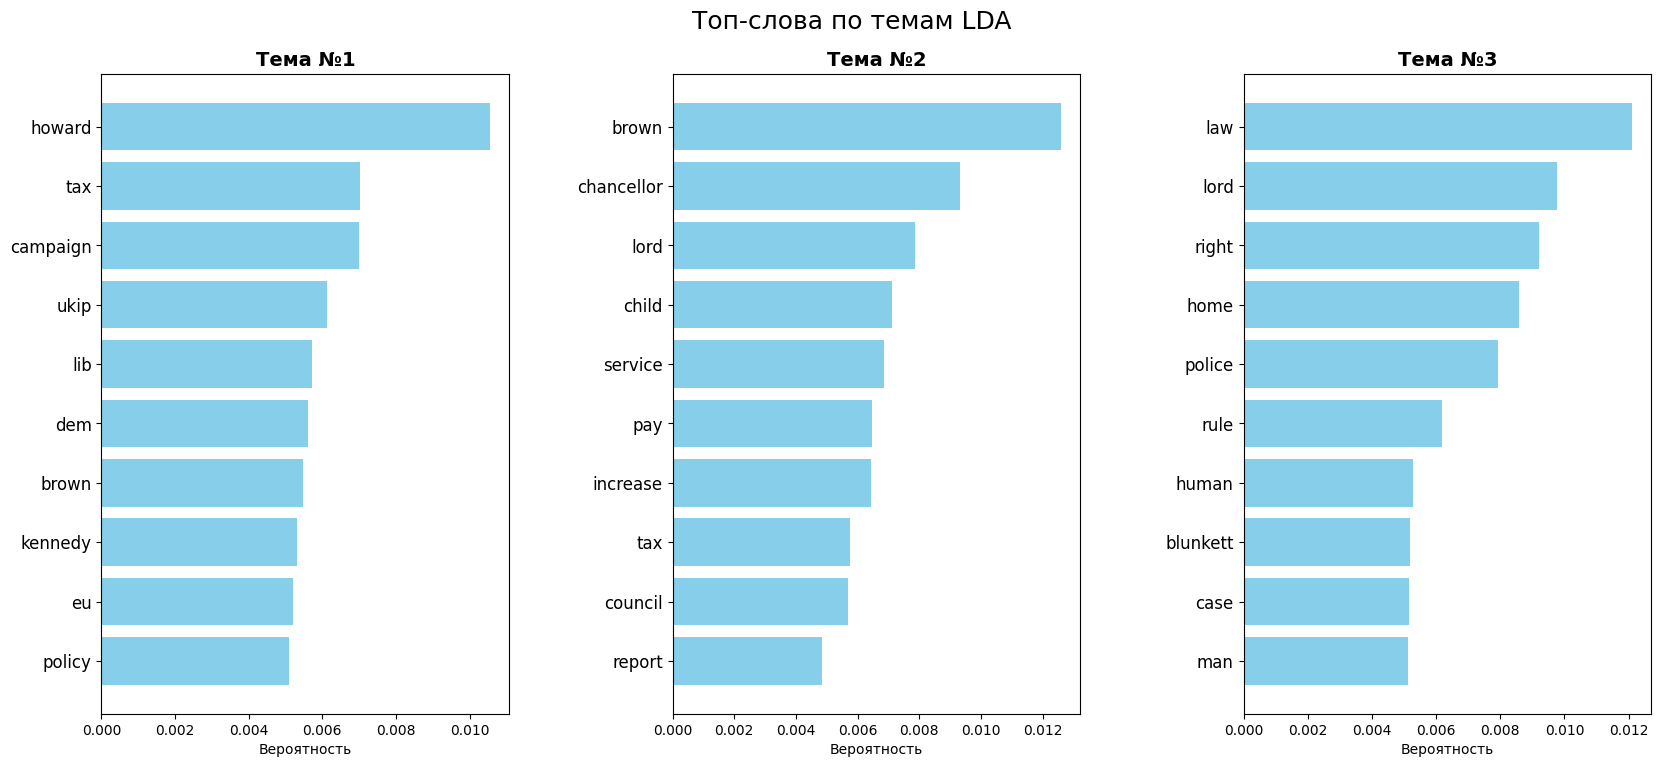

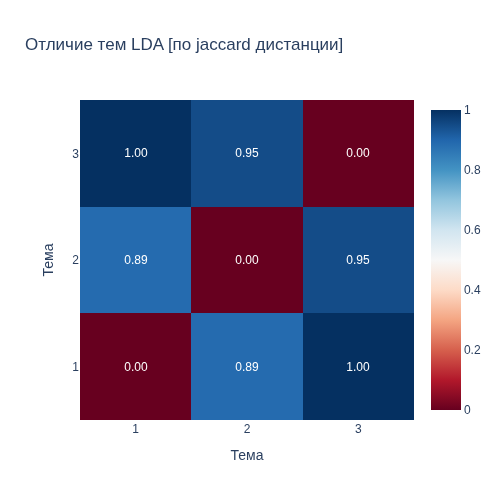

In [13]:
politics_df = df.text[df["label"] == 'politics']

# стоп-слова для politics
politics_stop_words = {
    "mr", "mp", "tory"
}
visualize_class_topics(politics_df, politics_stop_words, no_above=0.3)

По теме 'politics' подобраны три темы, сильно отличающиеся по jaccard дистанции.\
&emsp;&emsp; Первая тема - активисты, кампании и политика британской партии независимости (UKIP).\
&emsp;&emsp; Вторая тема - активность (service, tax, report) канцлера (казначейства?) лорда Брауна.\
&emsp;&emsp; Третья тема - законы/правила/права касательно лордов,полиции,человека.

## Рассмотрим тему 'tech'

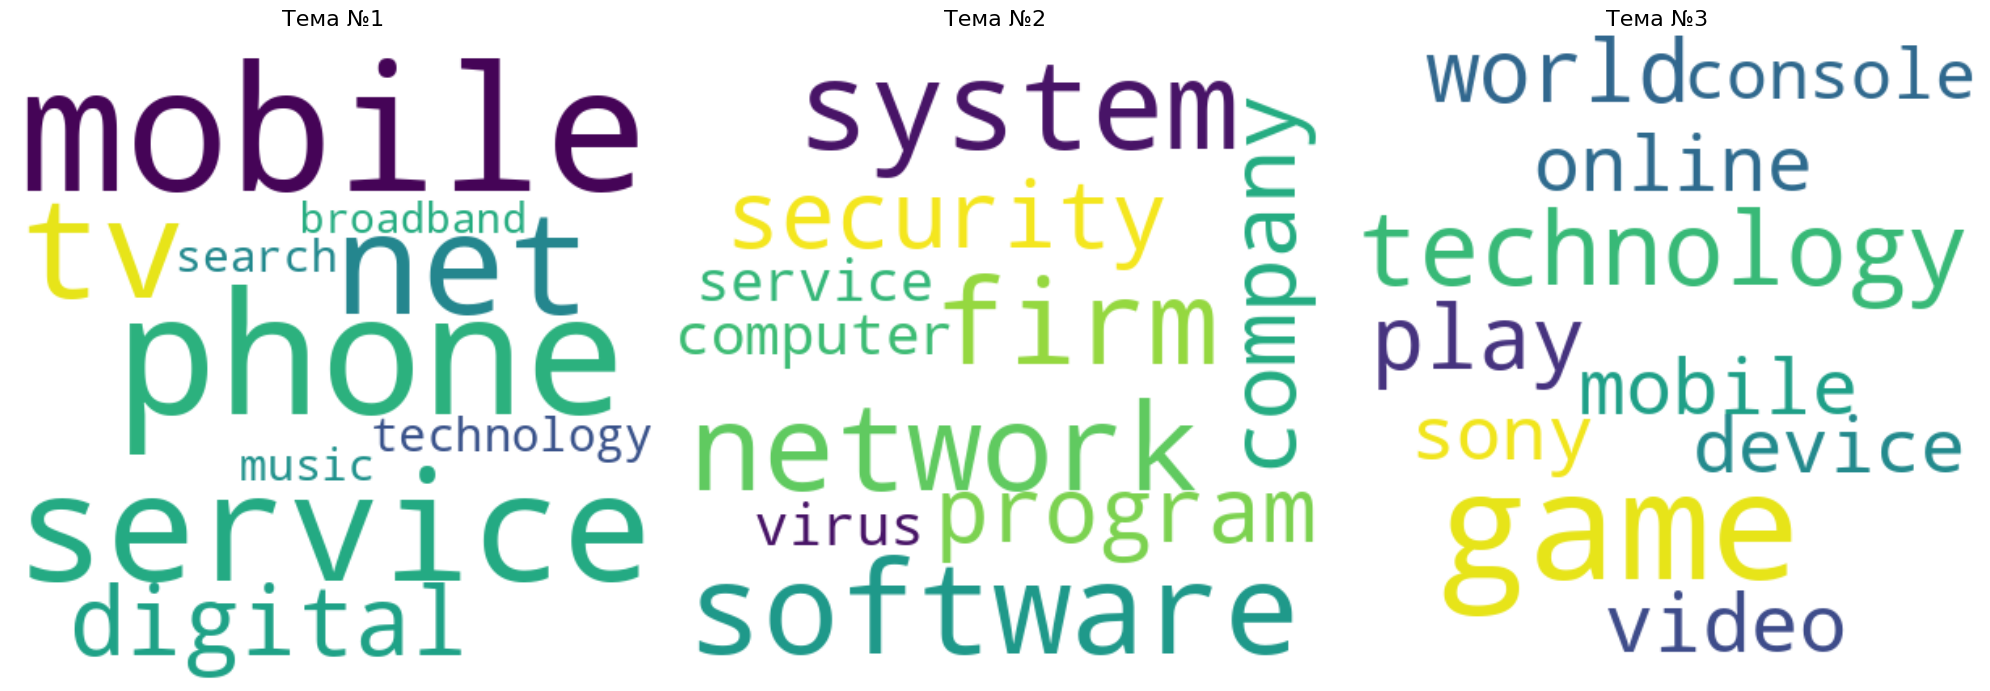

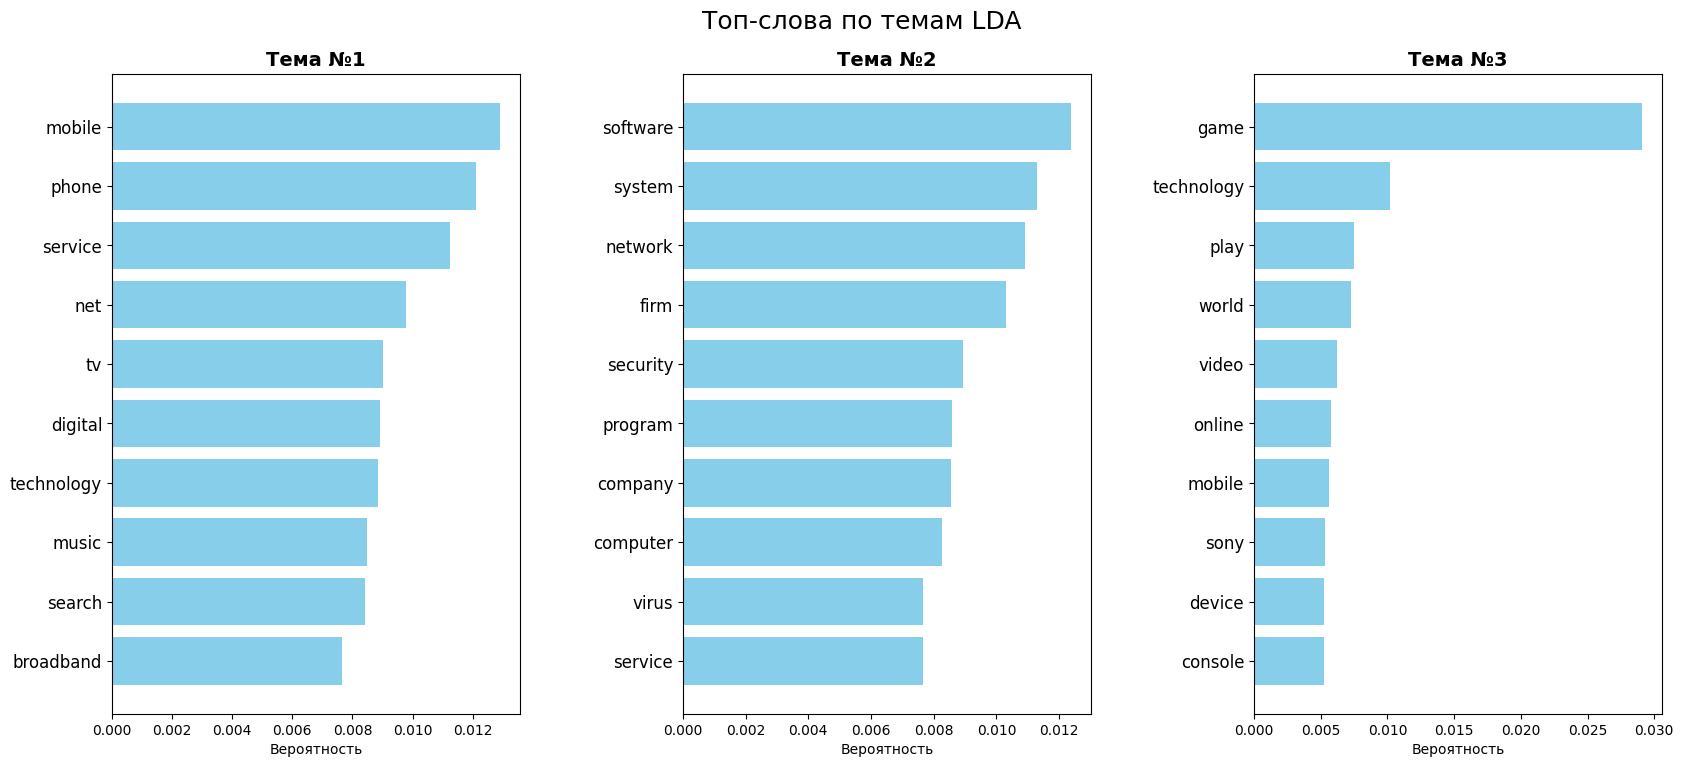

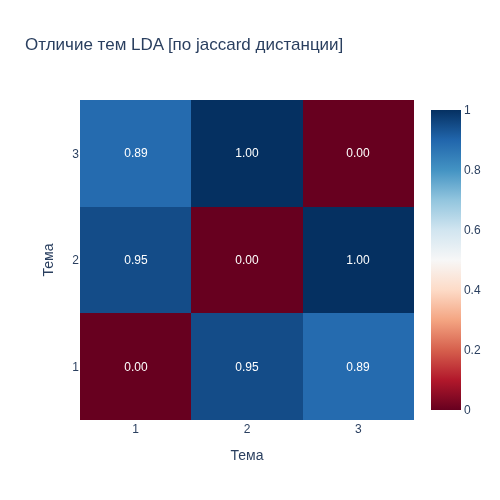

In [14]:
tech_df = df.text[df["label"] == 'tech']

# стоп-слова для tech
tech_stop_words = {
    'one', 'two', 'three', 'four', 'five', 'six',
    "mr", "like", "people", "site", "user"
}
visualize_class_topics(tech_df, tech_stop_words)

По теме 'tech' подобраны три темы, сильно отличающиеся по jaccard дистанции.\
&emsp;&emsp; Первая тема - обслуживание цифровых устройств (мобильных телефонов, телевизоров, сетевых устройств).\
&emsp;&emsp; Вторая тема - ПО/программы (для компаний?) по сетевой безопасности, защите от компьютерных вирусов.\
&emsp;&emsp; Третья тема - технологии мобильных, консольных, онлайн, видео- игр.